from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report)
TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
recall/sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP) 

In [2]:
from sklearn.tree import DecisionTreeClassifier

In [3]:
DecisionTreeClassifier??

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Source:        
class DecisionTreeClassifier(ClassifierMixin, BaseDecisionTree):
    """A decision tree classifier.

    Read more in the :ref:`User Guide <tree>`.

    Parameters
    ----------
    criterion : {"gini", "entropy", "log_loss"}, default="gini"
        The function to measure the quality of a split. Supported criteria are
        "gini" for the Gini impurity and "log_loss" and "entropy" both for the
        Shannon information gain, see :ref:`tree_mathematical_formulation`.

    splitter : {"best", "random"}, default="best"
        The strategy used to choose the split at each node. Supported
        strategies are 

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv('CSV/drug200.csv')
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [55]:
df = pd.get_dummies(df, columns=['Sex', 'BP', 'Cholesterol'], drop_first = True)
df

,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,drugY,False,False,False,False
1,47,13.093,drugC,True,True,False,False
2,47,10.114,drugC,True,True,False,False
3,28,7.798,drugX,False,False,True,False
4,61,18.043,drugY,False,True,False,False
...,...,...,...,...,...,...,...
195,56,11.567,drugC,False,True,False,False
196,16,12.006,drugC,True,True,False,False
197,52,9.894,drugX,True,False,True,False
198,23,14.020,drugX,True,False,True,True


In [56]:
X = df.drop(columns=['Drug'])
y = df['Drug']

In [57]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(criterion='entropy', max_depth = 5, random_state=42).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
print(accuracy_score(ytest, ypred))

1.0


In [58]:
print(confusion_matrix(ytest, ypred))

[[ 7  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  6  0  0]
 [ 0  0  0 18  0]
 [ 0  0  0  0 26]]


In [59]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



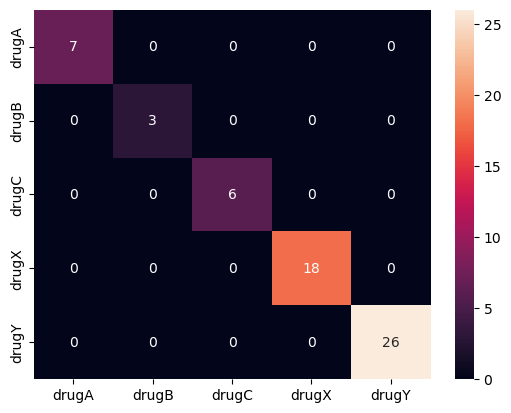

In [60]:
sns.heatmap(confusion_matrix(ytest, ypred), annot = True, xticklabels=model.classes_, yticklabels=model.classes_)
plt.show()

In [61]:
df.iloc[5]

Age                      22
Na_to_K               8.607
Drug                  drugX
Sex_M                 False
BP_LOW                False
BP_NORMAL              True
Cholesterol_NORMAL    False
Name: 5, dtype: object

In [62]:
Xtrain

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
169,20,11.262,False,False,False,False
97,56,25.395,False,False,False,False
31,74,9.567,True,False,False,False
12,43,15.376,True,True,False,False
35,46,7.285,True,False,True,True
...,...,...,...,...,...,...
106,22,11.953,True,False,True,False
14,50,12.703,False,False,True,False
92,29,29.450,False,False,False,False
179,67,15.891,False,False,True,False


In [63]:
print(model.predict([[22, 8.607, 0,0,1,0]]))

['drugX']


In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [30]:
df = pd.read_csv('CSV/loan_approval.csv')
df

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes
2,35,58000.0,690,150000.0,1,Graduate,Yes,Rural,2,Yes
3,28,26000.0,590,100000.0,0,Not Graduate,No,Urban,1,No
4,50,85000.0,810,250000.0,3,Graduate,No,Semiurban,0,Yes
5,31,46000.0,640,130000.0,1,Graduate,Yes,Rural,1,No
6,39,67000.0,730,180000.0,2,Graduate,No,Urban,0,Yes
7,29,31000.0,610,110000.0,0,Not Graduate,No,Rural,2,No
8,45,79000.0,800,230000.0,2,Graduate,No,Semiurban,0,Yes
9,33,52000.0,675,145000.0,1,Graduate,Yes,Urban,1,Yes


In [31]:
df.head()

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes
2,35,58000.0,690,150000.0,1,Graduate,Yes,Rural,2,Yes
3,28,26000.0,590,100000.0,0,Not Graduate,No,Urban,1,No
4,50,85000.0,810,250000.0,3,Graduate,No,Semiurban,0,Yes


In [32]:
df.shape

(13, 10)

In [33]:
df.dtypes

Age                int64
Income           float64
CreditScore        int64
LoanAmount       float64
Dependents         int64
Education         object
SelfEmployed      object
PropertyArea      object
PreviousLoans      int64
LoanApproved      object
dtype: object

In [34]:
df.isnull().sum()

Age              0
Income           1
CreditScore      0
LoanAmount       1
Dependents       0
Education        0
SelfEmployed     0
PropertyArea     0
PreviousLoans    0
LoanApproved     0
dtype: int64

In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

In [37]:
df.isnull().sum()

Age              0
Income           0
CreditScore      0
LoanAmount       0
Dependents       0
Education        0
SelfEmployed     0
PropertyArea     0
PreviousLoans    0
LoanApproved     0
dtype: int64

In [38]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12    False
dtype: bool

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
12    False
dtype: bool

In [52]:
df.dtypes

Age                         int64
Income                    float64
CreditScore                 int64
LoanAmount                float64
Dependents                  int64
PreviousLoans               int64
LoanApproved               object
Education_Not Graduate       bool
SelfEmployed_Yes             bool
PropertyArea_Semiurban       bool
PropertyArea_Urban           bool
dtype: object

In [42]:
df = pd.get_dummies(df, columns = ['Education', 'SelfEmployed', 'PropertyArea'], drop_first = True)

In [43]:
df

,Age,Income,CreditScore,LoanAmount,Dependents,PreviousLoans,LoanApproved,Education_Not Graduate,SelfEmployed_Yes,PropertyArea_Semiurban,PropertyArea_Urban
0,25,35000.0,620,120000.0,0,1,No,False,False,False,True
1,42,72000.0,780,200000.0,2,0,Yes,False,False,True,False
2,35,58000.0,690,150000.0,1,2,Yes,False,True,False,False
3,28,26000.0,590,100000.0,0,1,No,True,False,False,True
4,50,85000.0,810,250000.0,3,0,Yes,False,False,True,False
5,31,46000.0,640,130000.0,1,1,No,False,True,False,False
6,39,67000.0,730,180000.0,2,0,Yes,False,False,False,True
7,29,31000.0,610,110000.0,0,2,No,True,False,False,False
8,45,79000.0,800,230000.0,2,0,Yes,False,False,True,False
9,33,52000.0,675,145000.0,1,1,Yes,False,True,False,True


In [44]:
X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
model = KNeighborsClassifier(n_neighbors=3).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

In [46]:
print(accuracy_score(ytest, ypred))
print(confusion_matrix(ytest, ypred))

0.6666666666666666
[[1 0]
 [1 1]]


In [47]:
TN, FP, FN, TP = confusion_matrix(ytest, ypred).ravel()
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP) 

In [48]:
print(recall)
print(recall)
print((2 * precision * recall)/(precision + recall))

0.5
0.5
0.6666666666666666


In [51]:
model1 = DecisionTreeClassifier(criterion='entropy').fit(Xtrain, ytrain)
ypred1 = model1.predict(Xtest)
print(accuracy_score(ytest, ypred1))
TN, FP, FN, TP = confusion_matrix(ytest, ypred1).ravel()
recall1 = TP / (TP + FN)
specificity1 = TN / (TN + FP)
precision1 = TP / (TP + FP) 
print(recall1)
print(precision1)
print((2 * precision1 * recall1)/(precision1 + recall1))

0.6666666666666666
0.5
1.0
0.6666666666666666
